In [20]:
import scvelo as scv
import scanpy as sc
import velocyto as vcy
import cellrank as cr
import loompy as lp

from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import interp1d
from pathlib import Path

import numpy as np
import pandas as pd
import anndata as ad

import matplotlib.pyplot as plt

import os
import sys
import logging

In [36]:
adata_file = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/male_adata_stream_input.h5ad'
out_dir = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/stream_outs"

In [66]:
adata = sc.read_h5ad(adata_file)

In [67]:
#find if adata has var names starting with 'mt-' and print the names of such genes
adata.var["mt"] = adata.var_names.str.startswith("mt-")
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))
adata.var["hb"] = adata.var_names.str.contains("^Hb[^(p)]")
adata.var["linc"] = adata.var_names.str.contains("Linc")

In [68]:
colormap = {
    'WT': '#4169E1',     # royal blue
    'KO': '#FF69B4'      # hot pink
}

In [69]:
categories = adata.obs['condition'].cat.categories
display(categories)
display(adata.obs['condition'].value_counts())

Index(['KO', 'WT'], dtype='object')

condition
KO    16809
WT    13095
Name: count, dtype: int64

In [70]:
# First, make sure the colors are in the same order as the categories
colors = [colormap[cat] for cat in categories]
# Set the colors in adata.uns
adata.uns['condition_colors'] = colors

### Filter data before normalisation

In [71]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

In [73]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=150)
sc.pp.filter_genes(adata, min_cells=5)
adata = adata[:, (~adata.var['mt'] & ~adata.var['ribo'] & ~adata.var['hb'] & ~adata.var['linc'])] # Filter mitochondrial, linc, ribosomal, haemoglobin genes
print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

/ocean/projects/cis240075p/asachan/.conda/envs/scvelo/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


Number of cells after filtering of low quality cells: 18360


In [74]:
display(adata.obs['condition'].value_counts())

condition
KO    10108
WT     8252
Name: count, dtype: int64

In [75]:
# normalize data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/ocean/projects/cis240075p/asachan/.conda/envs/scvelo/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


/ocean/projects/cis240075p/asachan/.conda/envs/scvelo/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


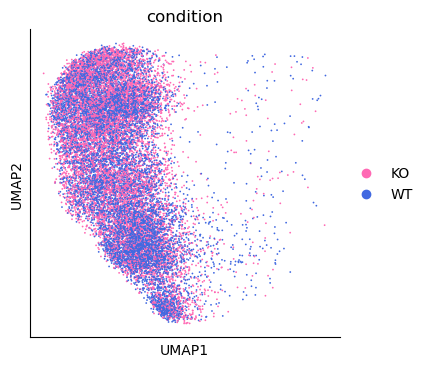

In [76]:
sc.pl.umap(adata, color=['condition'])

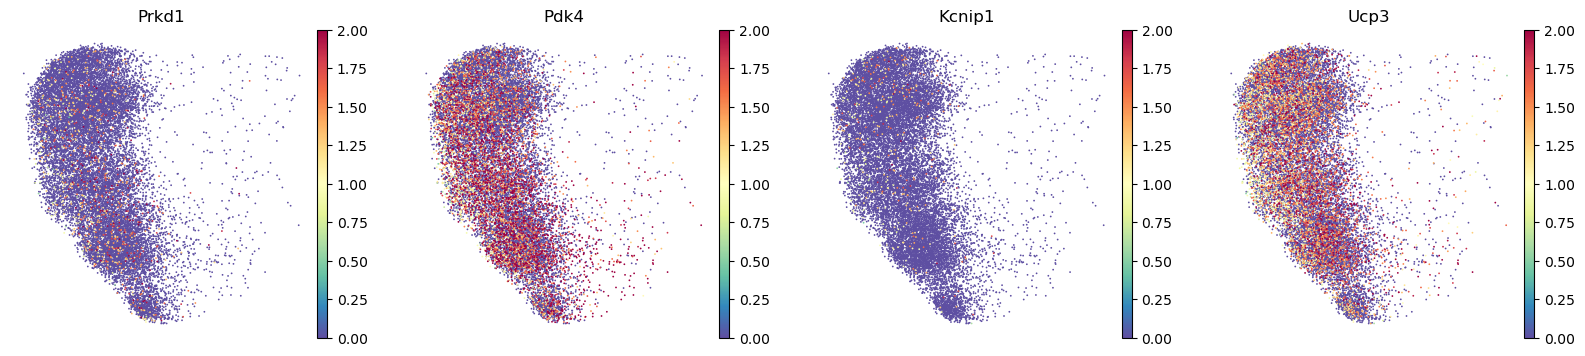

In [77]:
# pre imputation expression of some genes
sc.pl.embedding(
    adata,
    basis="umap",
    color=["Prkd1", "Pdk4", "Kcnip1", "Ucp3"],
    vmin=0,
    vmax=2,
    frameon=False,
)
plt.show()

### Cleanup the X matrix (normalized counts)

In [78]:
import scipy.sparse as sp
X = adata.X

In [79]:
if sp.issparse(X):
    data = X.data
    data[np.isnan(data)] = 0
    X.eliminate_zeros()
else:
    np.nan_to_num(X, copy=False)  # in-place: NaN->0, inf->large finite

In [80]:
n_nans = np.isnan(X.data).sum() if sp.issparse(X) else np.isnan(X).sum()
display(n_nans)
display(adata.X.size)

0

3752590

In [81]:
display(adata.X)

<18360x2631 sparse matrix of type '<class 'numpy.float32'>'
	with 3752590 stored elements in Compressed Sparse Row format>

### Pre-proc for diffusion maps

In [82]:
adata

AnnData object with n_obs × n_vars = 18360 × 2631
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm',

In [83]:
def dim_reduction(adata):
    #Scale before running PCA
    sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
    sc.pp.scale(adata, max_value=10)
    sc.pp.pca(adata)
    sc.pl.pca_variance_ratio(adata, n_pcs=20, log=True)
    return adata

In [84]:
print(adata.X.shape)
print(adata.X.max())
print(adata.X.min())

(18360, 2631)
5.0927386
0.0


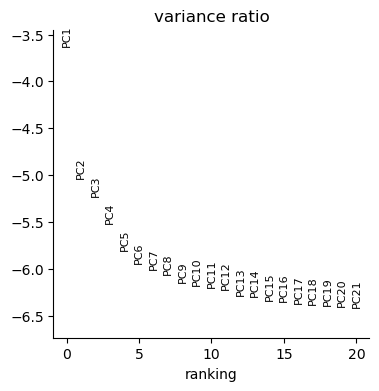

In [85]:
adata = dim_reduction(adata)

/ocean/projects/cis240075p/asachan/.conda/envs/scvelo/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


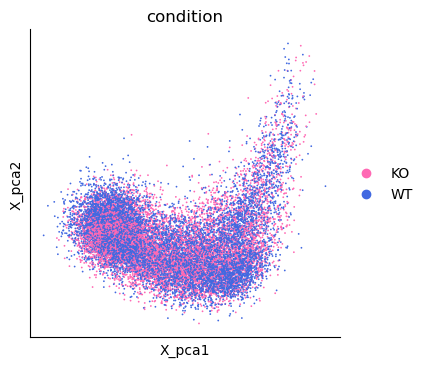

In [86]:
# plot using X_pca
sc.pl.embedding(adata, basis='X_pca', color=['condition'])

## Run diffusion maps

In [87]:
import palantir
palantir.utils.run_diffusion_maps(adata,n_components=8) #n_components, select from the plot above, knn = 30 by default for graph construction
adata


AnnData object with n_obs × n_vars = 18360 × 2631
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm',

/ocean/projects/cis240075p/asachan/.conda/envs/scvelo/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


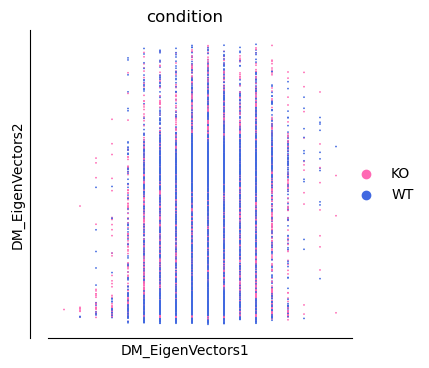

In [88]:
sc.pl.embedding(adata, basis='DM_EigenVectors', color=['condition'])

In [89]:
palantir.utils.run_magic_imputation(adata)

array([[0.        , 0.        , 0.        , ..., 0.        , 0.09226999,
        0.05334128],
       [0.        , 0.09040429, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.0441772 , 0.        ,
        0.04474213],
       ...,
       [0.        , 0.03398811, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.03049449],
       [0.        , 0.        , 0.        , ..., 0.01755358, 0.02881178,
        0.0250843 ]], dtype=float32)

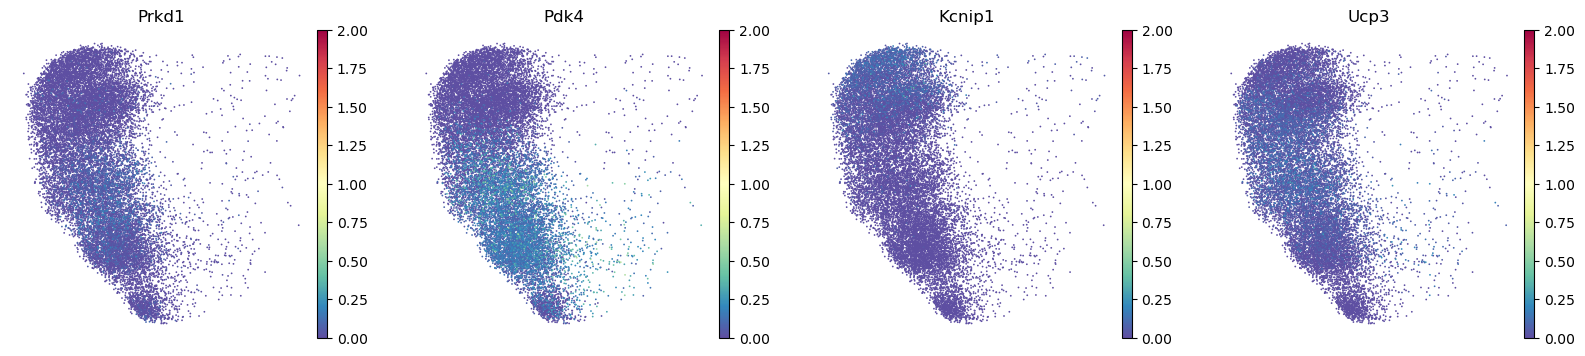

In [90]:
# post imputation expression of 6 TFs
sc.pl.embedding(
    adata,
    basis="umap",
    layer="MAGIC_imputed_data",
    color=["Prkd1", "Pdk4", "Kcnip1", "Ucp3"],
    vmin=0,
    vmax=2,
    frameon=False,
)
plt.show()

In [ ]:
# save the imputed adata
adata.write_h5ad(os.path.join(out_dir, "male_type2_fibers_imputed_v2.h5ad"))